Loaded UE1_final_data_S5_CPU_Control.csv: 370 data points
Loaded UE2_final_data_S5_CPU_Control.csv: 304 data points
Loaded UE3_final_data_S5_CPU_Control.csv: 240 data points
Loaded UE4_final_data_S5_CPU_Control.csv: 164 data points
Loaded UE5_final_data_S5_CPU_Control.csv: 90 data points
Loaded UE3_final_data.csv: 240 data points
Loaded UE4_final_data.csv: 164 data points
Loaded UE5_final_data.csv: 90 data points


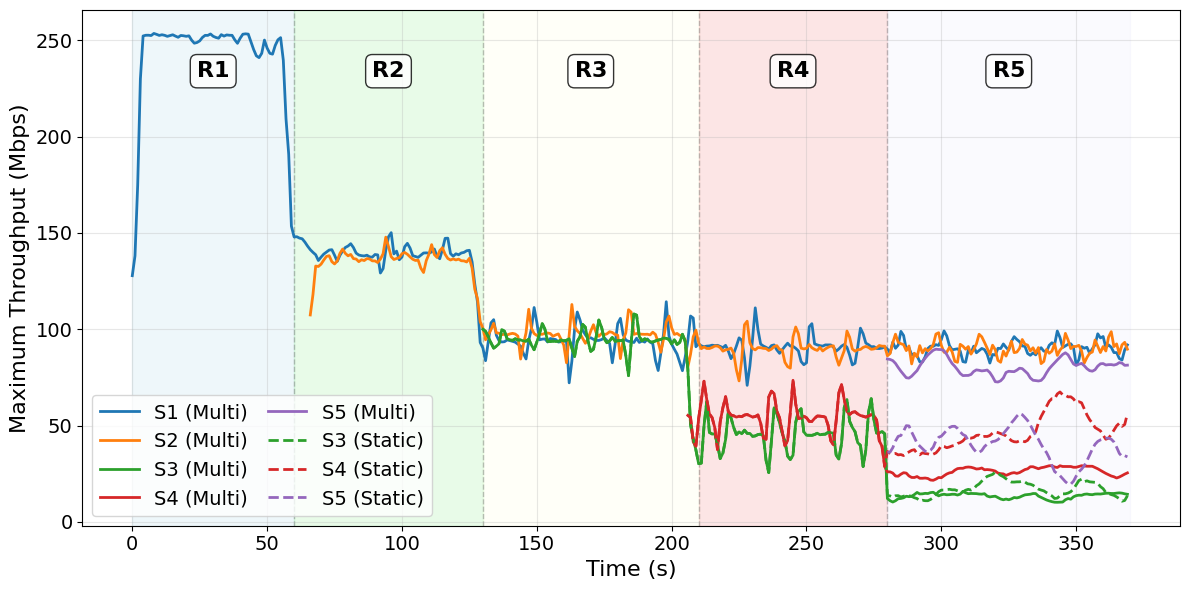

In [34]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Directory containing the final data files
DATA_DIR = "./aio"

# Create the plot
plt.figure(figsize=(12, 6))

# Get all CSV files
all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
all_files.sort()

# Separate files: without CPU control and with CPU control
files_without_cpu = [f for f in all_files if "_S5_CPU_Control" not in f]
files_with_cpu = [f for f in all_files if "_S5_CPU_Control" in f]

# Extract UE names and match them
ue_names_without = {f.replace("_final_data.csv", ""): f for f in files_without_cpu}
ue_names_with_cpu = {f.replace("_final_data_S5_CPU_Control.csv", ""): f for f in files_with_cpu}

# Define colors for each UE (using matplotlib's default color cycle)
colors = plt.cm.tab10(range(10))  # Get 10 distinct colors
ue_color_map = {}

# Get all unique UE names and assign colors
all_ue_names = sorted(set(list(ue_names_without.keys()) + list(ue_names_with_cpu.keys())))
for idx, ue_name in enumerate(all_ue_names):
    ue_color_map[ue_name] = colors[idx % len(colors)]

# Plot files with CPU control (continuous lines)
# Skip UE1 and UE2 - only plot without CPU control for them
for ue_name, filename in sorted(ue_names_with_cpu.items()):

    try:
        path = os.path.join(DATA_DIR, filename)
        df = pd.read_csv(path)
        plt.plot(df["x"], df["y"], 
                label=f"S{ue_name[-1]} (Multi)", 
                linestyle='-',  # continuous line
                color=ue_color_map[ue_name],
                linewidth=2)
        print(f"Loaded {filename}: {len(df)} data points")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

# Plot files without CPU control (dashed lines)
for ue_name, filename in sorted(ue_names_without.items()):
    # Skip UE1 and UE2 - only plot without CPU control for them
    if ue_name in ["UE1", "UE2"]:
        continue
    try:
        path = os.path.join(DATA_DIR, filename)
        df = pd.read_csv(path)
        plt.plot(df["x"], df["y"], 
                label=f"S{ue_name[-1]} (Static)", 
                linestyle='--',  # dashed line
                color=ue_color_map[ue_name],
                linewidth=2)
        print(f"Loaded {filename}: {len(df)} data points")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("Maximum Throughput (Mbps)", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, alpha=0.3)

# Define the 5 vertical regions
region_boundaries = [0, 60, 130, 210, 280, 370]
region_colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lavender']
region_labels = ['R1', 'R2', 'R3', 'R4', 'R5']

# Add shaded vertical regions
ax = plt.gca()
ymin, ymax = ax.get_ylim()
for i in range(len(region_boundaries) - 1):
    ax.axvspan(region_boundaries[i], region_boundaries[i+1], 
               alpha=0.2, color=region_colors[i], zorder=0)
    # Add region label in the middle of each region
    region_center = (region_boundaries[i] + region_boundaries[i+1]) / 2
    ax.text(region_center, ymax * 0.9, region_labels[i], 
            ha='center', va='top', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=2)

# Add vertical lines to separate regions
for boundary in region_boundaries[1:-1]:  # Skip first and last
    ax.axvline(x=boundary, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=1)

# Reset y-axis limits to original
ax.set_ylim(ymin, ymax)

# Organize legend: separate continuous and dashed lines into two columns
handles, labels = plt.gca().get_legend_handles_labels()
# Separate into continuous (Multi) and dashed (Static)
continuous_handles = []
continuous_labels = []
dashed_handles = []
dashed_labels = []

for handle, label in zip(handles, labels):
    if '(Multi)' in label:
        continuous_handles.append(handle)
        continuous_labels.append(label)
    elif '(Static)' in label:
        dashed_handles.append(handle)
        dashed_labels.append(label)

# Combine: first column continuous, second column dashed
all_handles = continuous_handles + dashed_handles
all_labels = continuous_labels + dashed_labels

plt.legend(all_handles, all_labels, fontsize=14, ncol=2, 
           columnspacing=1.0, handlelength=2.0)
plt.tight_layout()

plt.savefig("5_Slices_with_and_without_CPU_control.pdf")


plt.show()

25
Loaded UE1_final_data_S5_CPU_Control.csv: 370 data points
25
Loaded UE2_final_data_S5_CPU_Control.csv: 304 data points
30
Loaded UE3_final_data_S5_CPU_Control.csv: 240 data points
45
Loaded UE4_final_data_S5_CPU_Control.csv: 164 data points
90
Loaded UE5_final_data_S5_CPU_Control.csv: 90 data points
Loaded UE3_final_data.csv: 240 data points
Loaded UE4_final_data.csv: 164 data points
Loaded UE5_final_data.csv: 90 data points


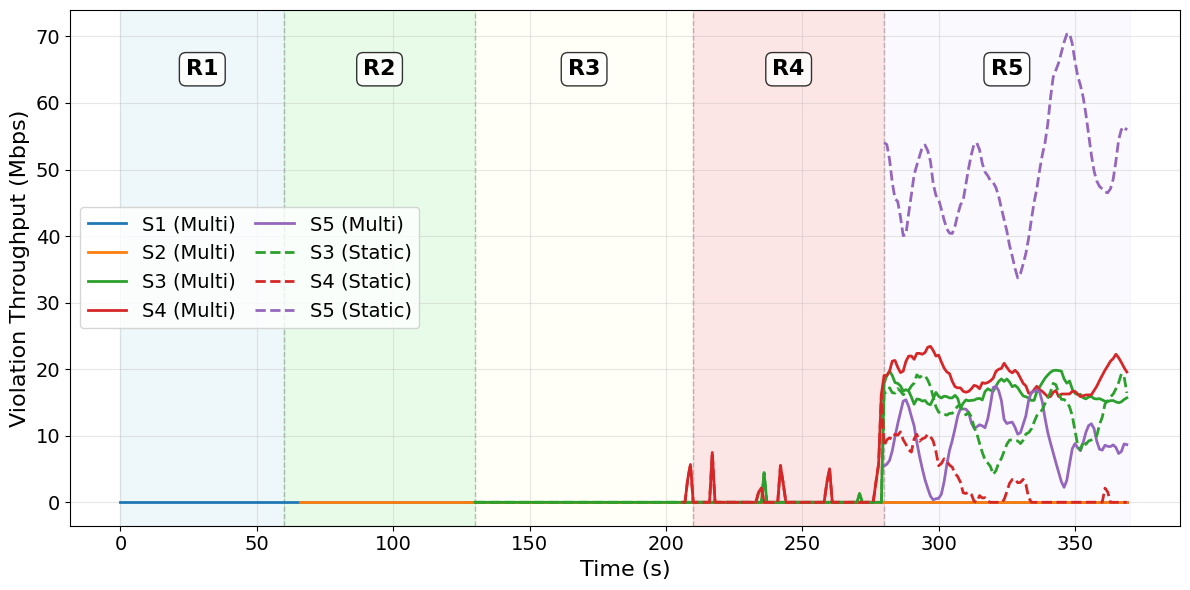

In [49]:
import os
from re import S
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Directory containing the final data files
DATA_DIR = "./aio"

expected_throughout = {
    "UE1": 25,
    "UE2": 25,
    "UE3": 30,
    "UE4": 45,
    "UE5": 90
}
# Create the plot
plt.figure(figsize=(12, 6))

# Get all CSV files
all_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
all_files.sort()

# Separate files: without CPU control and with CPU control
files_without_cpu = [f for f in all_files if "_S5_CPU_Control" not in f]
files_with_cpu = [f for f in all_files if "_S5_CPU_Control" in f]

# Extract UE names and match them
ue_names_without = {f.replace("_final_data.csv", ""): f for f in files_without_cpu}
ue_names_with_cpu = {f.replace("_final_data_S5_CPU_Control.csv", ""): f for f in files_with_cpu}

# Define colors for each UE (using matplotlib's default color cycle)
colors = plt.cm.tab10(range(10))  # Get 10 distinct colors
ue_color_map = {}

# Get all unique UE names and assign colors
all_ue_names = sorted(set(list(ue_names_without.keys()) + list(ue_names_with_cpu.keys())))
for idx, ue_name in enumerate(all_ue_names):
    ue_color_map[ue_name] = colors[idx % len(colors)]

# Plot files with CPU control (continuous lines)
# Skip UE1 and UE2 - only plot without CPU control for them
for ue_name, filename in sorted(ue_names_with_cpu.items()):

    try:
        path = os.path.join(DATA_DIR, filename)
        df = pd.read_csv(path)
        expected_throughput = expected_throughout[ue_name]
        print(expected_throughput)
        plt.plot(df["x"], np.clip(expected_throughput-df["y"], 0, None), 
                label=f"S{ue_name[-1]} (Multi)", 
                linestyle='-',  # continuous line
                color=ue_color_map[ue_name],
                linewidth=2)
        print(f"Loaded {filename}: {len(df)} data points")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

# Plot files without CPU control (dashed lines)
for ue_name, filename in sorted(ue_names_without.items()):
    # Skip UE1 and UE2 - only plot without CPU control for them
    if ue_name in ["UE1", "UE2"]:
        continue
    try:
        path = os.path.join(DATA_DIR, filename)
        df = pd.read_csv(path)
        expected_throughput = expected_throughout[ue_name]
        plt.plot(df["x"], np.clip(expected_throughput-df["y"], 0, None), 
                label=f"S{ue_name[-1]} (Static)", 
                linestyle='--',  # dashed line
                color=ue_color_map[ue_name],
                linewidth=2)
        print(f"Loaded {filename}: {len(df)} data points")
    except Exception as e:
        print(f"Error loading {filename}: {e}")

plt.xlabel("Time (s)", fontsize=16)
plt.ylabel("Violation Throughput (Mbps)", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, alpha=0.3)

# Define the 5 vertical regions
region_boundaries = [0, 60, 130, 210, 280, 370]
region_colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral', 'lavender']
region_labels = ['R1', 'R2', 'R3', 'R4', 'R5']

# Add shaded vertical regions
ax = plt.gca()
ymin, ymax = ax.get_ylim()
for i in range(len(region_boundaries) - 1):
    ax.axvspan(region_boundaries[i], region_boundaries[i+1], 
               alpha=0.2, color=region_colors[i], zorder=0)
    # Add region label in the middle of each region
    region_center = (region_boundaries[i] + region_boundaries[i+1]) / 2
    ax.text(region_center, ymax * 0.9, region_labels[i], 
            ha='center', va='top', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), zorder=2)

# Add vertical lines to separate regions
for boundary in region_boundaries[1:-1]:  # Skip first and last
    ax.axvline(x=boundary, color='gray', linestyle='--', linewidth=1, alpha=0.5, zorder=1)

# Reset y-axis limits to original
ax.set_ylim(ymin, ymax)

# Organize legend: separate continuous and dashed lines into two columns
handles, labels = plt.gca().get_legend_handles_labels()
# Separate into continuous (Multi) and dashed (Static)
continuous_handles = []
continuous_labels = []
dashed_handles = []
dashed_labels = []

for handle, label in zip(handles, labels):
    if '(Multi)' in label:
        continuous_handles.append(handle)
        continuous_labels.append(label)
    elif '(Static)' in label:
        dashed_handles.append(handle)
        dashed_labels.append(label)

# Combine: first column continuous, second column dashed
all_handles = continuous_handles + dashed_handles
all_labels = continuous_labels + dashed_labels

plt.legend(all_handles, all_labels, fontsize=14, ncol=2, 
           columnspacing=1.0, handlelength=2.0)
plt.tight_layout()

plt.savefig("5_Slices_with_and_without_CPU_control_Violation_Throughput.pdf")

plt.show()